# Image Basics — How Computers See Images

## Goal
Understand how images are represented as numbers.
Every CV model starts here — if you don't understand pixels, you don't understand CV.

## Key Questions
- What is a pixel?
- How are colors represented numerically?
- What is the difference between RGB and grayscale?
- How do image transformations work?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request

## 1. Images as Arrays
An image is just a 3D numpy array: (height, width, channels)
- Grayscale: (H, W) — one channel
- RGB: (H, W, 3) — three channels (Red, Green, Blue)
- Each pixel value: 0 (black) to 255 (white)

Image shape: (8, 8, 3)
Data type: uint8
Min value: 0, Max value: 255

Top-left pixel (Red): [255   0   0]
Top-right pixel (Green): [  0 255   0]
Bottom-left pixel (Blue): [  0   0 255]


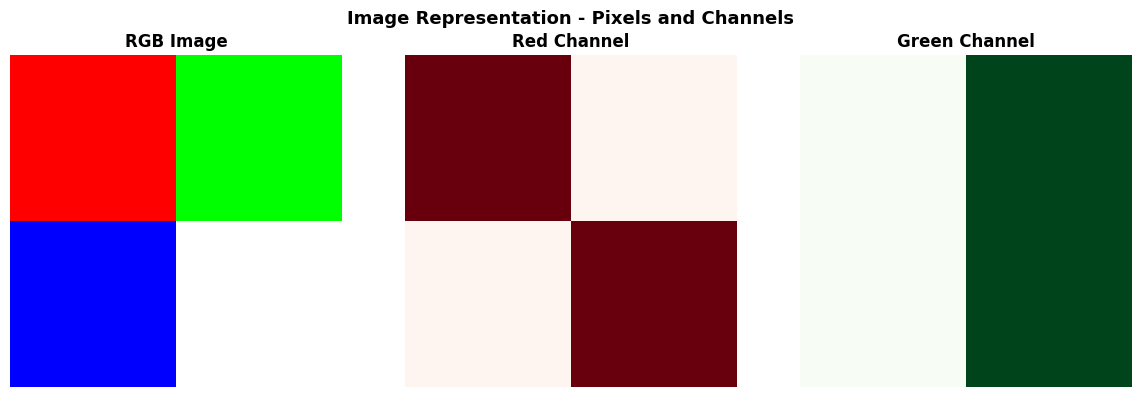

In [5]:
# Create a simple image from scratch
# 8x8 pixel image with a pattern
image = np.zeros((8, 8, 3), dtype=np.uint8)

# Red square in top-left
image[0:4, 0:4] = [255, 0, 0]

# Green square in top-right
image[0:4, 4:8] = [0, 255, 0]

# Blue square in bottom-left
image[4:8, 0:4] = [0, 0, 255]

# White square in bottom-right
image[4:8, 4:8] = [255, 255, 255]

print(f"Image shape: {image.shape}")
print(f"Data type: {image.dtype}")
print(f"Min value: {image.min()}, Max value: {image.max()}")
print(f"\nTop-left pixel (Red): {image[0, 0]}")
print(f"Top-right pixel (Green): {image[0, 7]}")
print(f"Bottom-left pixel (Blue): {image[7, 0]}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image, interpolation="nearest")
axes[0].set_title("RGB Image", fontweight="bold")
axes[0].axis("off")

axes[1].imshow(image[:, :, 0], cmap="Reds", interpolation="nearest")
axes[1].set_title("Red Channel", fontweight="bold")
axes[1].axis("off")

axes[2].imshow(image[:, :, 1], cmap="Greens", interpolation="nearest")
axes[2].set_title("Green Channel", fontweight="bold")
axes[2].axis("off")

plt.suptitle("Image Representation - Pixels and Channels", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("Image_basics.png", dpi=300)
plt.show()

## 2. Grayscale Conversion
Converting RGB to grayscale — one channel instead of three.
Formula: Gray = 0.299*R + 0.587*G + 0.114*B
(Green has highest weight — human eye is most sensitive to green)

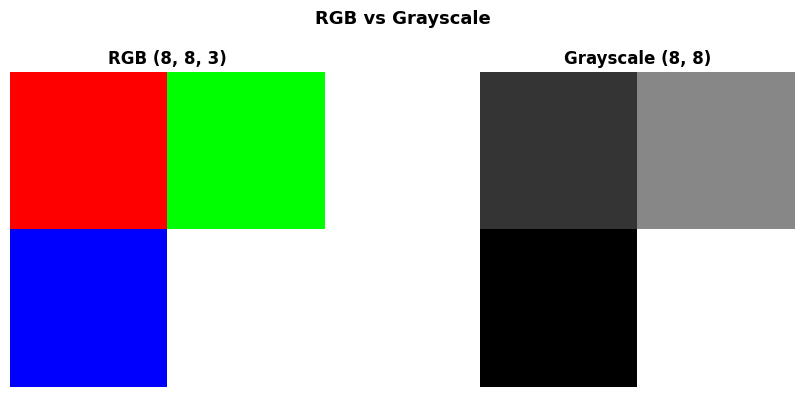

RGB shape: (8, 8, 3) - 3 channels
Grayscale shape: (8, 8) - 1 channel
Memory reduction: 192 bytes → 64 bytes


In [6]:
# Convert RGB to grayscale manually
def rgb_to_grayscale(image: np.ndarray) -> np.ndarray:
    """Convert RGB image to grayscale using luminosity formula."""
    return (0.299 * image[:,:,0] +
            0.587 * image[:,:,1] +
            0.114 * image[:,:,2]).astype(np.uint8)

gray = rgb_to_grayscale(image)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(image, interpolation="nearest")
axes[0].set_title(f"RGB {image.shape}", fontweight="bold")
axes[0].axis("off")

axes[1].imshow(gray, cmap="gray", interpolation="nearest")
axes[1].set_title(f"Grayscale {gray.shape}", fontweight="bold")
axes[1].axis("off")

plt.suptitle("RGB vs Grayscale", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("rgb_vs_grayscale.png", dpi=300)
plt.show()

print(f"RGB shape: {image.shape} - 3 channels")
print(f"Grayscale shape: {gray.shape} - 1 channel")
print(f"Memory reduction: {image.nbytes} bytes → {gray.nbytes} bytes")

## 3. Image Transformations
Basic operations every CV pipeline uses.

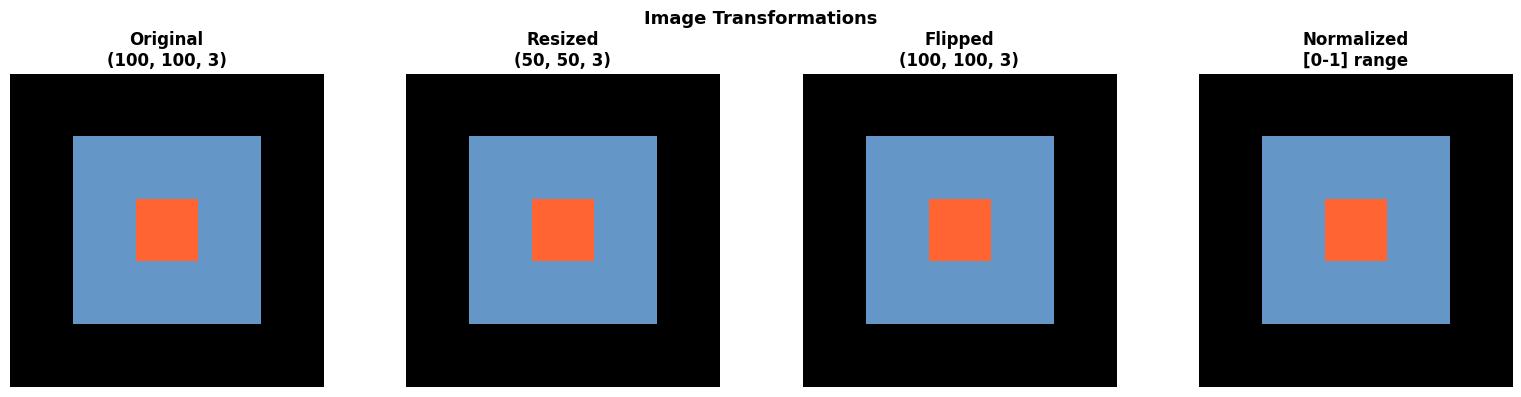

In [10]:
# Create a bigger test image
img = np.zeros((100, 100, 3), dtype=np.uint8)
img[20:80, 20:80] = [100, 150, 200] # Blue-ish rectangle
img[40:60, 40:60] = [255, 100, 50]  # orange square inside

def normalize(image: np.ndarray) -> np.ndarray:
    return image.astype(np.float32) / 255.0

def resize(image: np.ndarray, new_h: int, new_w: int) -> np.ndarray:
    """Simple nearest-neighbor resize."""
    h, w = image.shape[:2]
    row_idx = (np.arange(new_h) * h / new_h).astype(int)
    col_idx = (np.arange(new_w) * w / new_w).astype(int)
    return image[row_idx][:, col_idx]

def flip_horizontal(image: np.ndarray) -> np.ndarray:
    """Flip image horizontally."""
    return image[:, ::-1]

resized = resize(img, 50, 50)
flipped = flip_horizontal(img)
normalized = normalize(img)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img)
axes[0].set_title(f"Original\n{img.shape}", fontweight="bold")
axes[0].axis("off")

axes[1].imshow(resized)
axes[1].set_title(f"Resized\n{resized.shape}", fontweight="bold")
axes[1].axis("off")

axes[2].imshow(flipped)
axes[2].set_title(f"Flipped\n{flipped.shape}", fontweight="bold")
axes[2].axis("off")

axes[3].imshow(normalized)
axes[3].set_title(f"Normalized\n[0-1] range", fontweight="bold")
axes[3].axis("off")

plt.suptitle("Image Transformations", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("image_transformations.png", dpi=300)
plt.show()

## 4. Key Observations

## Image Representation
- An image is a 3D numpy array: (height, width, channels)
- Each pixel value: 0 (black) to 255 (white)
- RGB has 3 channels — Red, Green, Blue
- Grayscale has 1 channel — 3x less memory

## Grayscale Conversion
- Green has the highest weight (0.587) — human eye is most sensitive to green
- Blue has the lowest weight (0.114)
- Blue pixel → black in grayscale
- Green pixel → brightest in grayscale

## Transformations
- Resize: change spatial dimensions
- Flip: mirror the image — used for data augmentation
- Normalize: scale [0-255] to [0-1] — required before neural network input

## Key Insight
Every CV model sees numbers, not images.
Understanding this array representation is the foundation of everything else in CV.

## Next
How do filters detect features in images?
-> 02_filters_and_edges.ipynb